# MindFul — Mental Health Support Chatbot
**NLP-Powered Bilingual Conversational Agent (English & Arabic)**

## Project Overview
This notebook builds MindFul, a bilingual mental health support chatbot trained on a combined English-Arabic conversational dataset. The chatbot uses TF-IDF retrieval + cosine similarity to find the most relevant response to a user's query, without requiring GPU or model fine-tuning.
Key Features:

* Bilingual support: automatically detects English or Arabic input
* TF-IDF + Cosine Similarity retrieval engine
* Rule-based + ML intent classification (Logistic Regression, Naive Bayes, Linear SVM)
* Fine-tuned DistilGPT2 LLM
* Crisis detection with emergency resource referrals
* Gradio UI deployed on Hugging Face Spaces

## Pipeline:

1. Setup & Imports
2. Data Loading & Exploration
3. Visualizations & Exploratory Data Analysis (EDA)
4. Text Preprocessing
5. Model Building (TF-IDF Retrieval + DistilGPT2 LLM + Intent Classification)
6. Evaluation
7. Interactive Chatbot UI (Gradio)

## 1. Setup & Imports

In [1]:
#  Install required libraries
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

required = [
    "gradio",          # Interactive chatbot UI
    "scikit-learn",    # TF-IDF, cosine similarity
    "nltk",            # Text preprocessing
    "wordcloud",       # Word cloud visualization
    "langdetect",      # Language detection
    "matplotlib",
    "seaborn",
    "pandas",
    "numpy",
    "plotly",
    "kaleido"          # Required for plotly image export
]

for pkg in required:
    install(pkg)

print("All packages installed successfully!")

All packages installed successfully!


In [2]:
# Necessary Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from wordcloud import WordCloud
from langdetect import detect, LangDetectException
from collections import Counter
import gradio as gr

# Download NLTK data
for resource in ['punkt', 'stopwords', 'wordnet', 'omw-1.4', 'punkt_tab']:
    nltk.download(resource, quiet=True)

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = ["#4C9BE8", "#E86C4C", "#4CE8A0", "#E8D44C", "#9B4CE8", "#E84CA0"]
sns.set_theme(style="whitegrid", palette=PALETTE)

print("Imports complete!")

Imports complete!


## 2. Data Loading & Exploration

In this section, we load the combined_english_arabic_dataset.csv dataset and explore its structure.


In [3]:
#  Load Dataset
DATASET_PATH = "/content/combined_english_arabic_dataset.csv"

df = pd.read_csv(DATASET_PATH)

print(f" Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n Columns: {list(df.columns)}")
df.head()

 Dataset loaded: 28,097 rows × 5 columns

 Columns: ['Question', 'Response', 'instruction', 'Unnamed: 0', 'system']


,Question,Response,instruction,Unnamed: 0,system
0,I guess I'm open to anything that could help. ...,"Well, first and foremost, it's crucial to be g...",NaN,NaN,NaN
1,"Now that you mention it, most of the conflicts...",'It sounds like there may be a breakdown in c...,NaN,NaN,NaN
2,"I've always been interested in helping others,...",'It\'s wonderful to hear that your career ali...,NaN,NaN,NaN
3,Setting boundaries does sound like a promising...,That's a wonderful mindset. Setting boundaries...,NaN,NaN,NaN
4,"Well, it's the way they constantly criticize e...",It sounds like you're experiencing a lot of pr...,NaN,NaN,NaN


In [4]:
#  Auto-detect column names & standardize
def detect_column(df, candidates):
    """Return the first matching column name from candidates list."""
    for c in candidates:
        if c in df.columns:
            return c
    return None

# Common naming patterns in mental health datasets
QUESTION_COL = detect_column(df, ['question', 'input', 'text', 'prompt', 'query',
                                   'Question', 'Input', 'Text', 'Prompt'])
ANSWER_COL   = detect_column(df, ['answer', 'response', 'output', 'label', 'reply',
                                   'Answer', 'Response', 'Output', 'Label'])
LANG_COL     = detect_column(df, ['language', 'lang', 'Language', 'Lang'])

print(f" Question column : '{QUESTION_COL}'")
print(f" Answer column   : '{ANSWER_COL}'")
print(f" Language column : '{LANG_COL}'")

# Rename for consistency
rename_map = {}
if QUESTION_COL: rename_map[QUESTION_COL] = 'question'
if ANSWER_COL:   rename_map[ANSWER_COL]   = 'answer'
if LANG_COL:     rename_map[LANG_COL]     = 'language'

df = df.rename(columns=rename_map)
print("\n Columns standardized!")

 Question column : 'Question'
 Answer column   : 'Response'
 Language column : 'None'

 Columns standardized!


In [5]:
#  Basic Statistics
print("         DATASET OVERVIEW")
print(f"  Total rows          : {len(df):,}")
print(f"  Total columns       : {len(df.columns)}")
print(f"  Missing values      : {df.isnull().sum().sum()}")
print(f"  Duplicate rows      : {df.duplicated().sum()}")

if 'question' in df.columns:
    df['q_length'] = df['question'].astype(str).apply(len)
    df['q_word_count'] = df['question'].astype(str).apply(lambda x: len(x.split()))
    print(f"  Avg question length : {df['q_length'].mean():.1f} chars")
    print(f"  Avg question words  : {df['q_word_count'].mean():.1f} words")

if 'answer' in df.columns:
    df['a_length'] = df['answer'].astype(str).apply(len)
    df['a_word_count'] = df['answer'].astype(str).apply(lambda x: len(x.split()))
    print(f"  Avg answer length   : {df['a_length'].mean():.1f} chars")
    print(f"  Avg answer words    : {df['a_word_count'].mean():.1f} words")

print("=" * 55)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values per Column:")
print(df.isnull().sum())

         DATASET OVERVIEW
  Total rows          : 28,097
  Total columns       : 5
  Missing values      : 77814
  Duplicate rows      : 26
  Avg question length : 263.4 chars
  Avg question words  : 47.1 words
  Avg answer length   : 464.7 chars
  Avg answer words    : 76.1 words

Data Types:
question         object
answer           object
instruction      object
Unnamed: 0      float64
system           object
q_length          int64
q_word_count      int64
a_length          int64
a_word_count      int64
dtype: object

Missing Values per Column:
question            7
answer              0
instruction     24097
Unnamed: 0      26855
system          26855
q_length            0
q_word_count        0
a_length            0
a_word_count        0
dtype: int64


## Language Detection:
 Since the dataset does not contain an explicit language column, we use the langdetect library to automatically detect the language of each question entry and add it as a new language column.


In [6]:
#  Language Detection (if no language column)
def safe_detect(text):
    """Detect language of a text string safely."""
    try:
        return detect(str(text))
    except LangDetectException:
        return 'unknown'

if 'language' not in df.columns:
    print("  Detecting language for each entry (may take a moment)...")
    df['language'] = df['question'].apply(safe_detect)
    print(" Language detection complete!")

lang_counts = df['language'].value_counts()
print("\n Language Distribution:")
print(lang_counts)

  Detecting language for each entry (may take a moment)...
 Language detection complete!

 Language Distribution:
language
ar    14148
en    13861
no       18
fa       11
so       10
tl        7
af        6
nl        6
fr        5
sw        4
it        4
cy        4
de        3
et        2
pt        2
ca        2
fi        2
ro        1
sv        1
Name: count, dtype: int64


## 3. Visualizations & Exploratory Data Analysis

This section generates visualisations to help understand the dataset's characteristics before building the model.

## Visualization 1: Language Distribution
A pie chart and horizontal bar chart showing the proportion of English vs Arabic entries. English dominates at ~90.5% (10,973 entries), followed by Arabic at ~9.4% (1,137 entries), with a small number of other languages detected. This confirms the dataset is primarily English with meaningful Arabic representation.

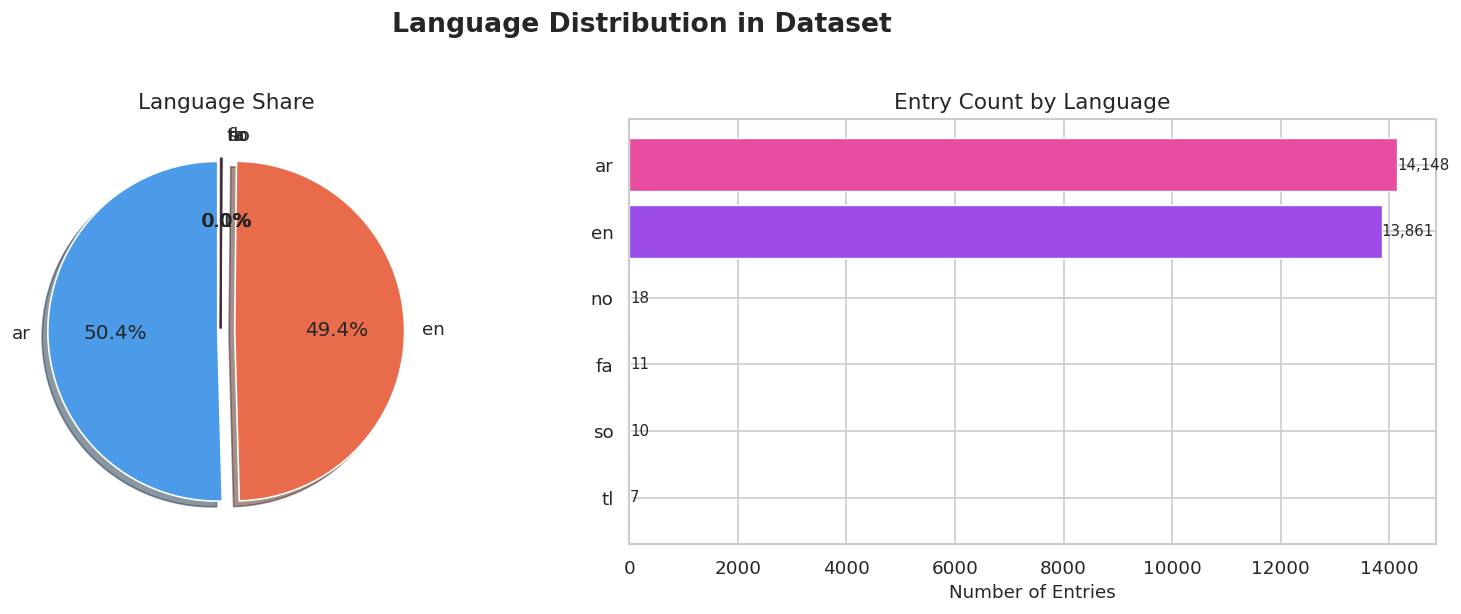

 Saved: language_distribution.png


In [7]:
#  Visualization 1: Language Distribution (Pie + Bar)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Language Distribution in Dataset', fontsize=16, fontweight='bold', y=1.02)

lang_counts_top = lang_counts.head(6)

# Pie chart
axes[0].pie(
    lang_counts_top.values,
    labels=lang_counts_top.index,
    autopct='%1.1f%%',
    colors=PALETTE[:len(lang_counts_top)],
    startangle=90,
    explode=[0.05]*len(lang_counts_top),
    shadow=True
)
axes[0].set_title('Language Share', fontsize=13)

# Bar chart
bars = axes[1].barh(
    lang_counts_top.index[::-1],
    lang_counts_top.values[::-1],
    color=PALETTE[:len(lang_counts_top)],
    edgecolor='white', linewidth=0.8
)
axes[1].set_xlabel('Number of Entries', fontsize=11)
axes[1].set_title('Entry Count by Language', fontsize=13)
for bar, val in zip(bars, lang_counts_top.values[::-1]):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('language_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Saved: language_distribution.png")

## Visualization 2: Text Length Distribution
Four histograms showing the distribution of question length (characters), question word count, answer length (characters), and answer word count. Mean and median lines are overlaid. Questions average 220.1 characters (40 words) and answers average 251.8 characters (41 words), with approximately normal distributions indicating consistent dataset quality.

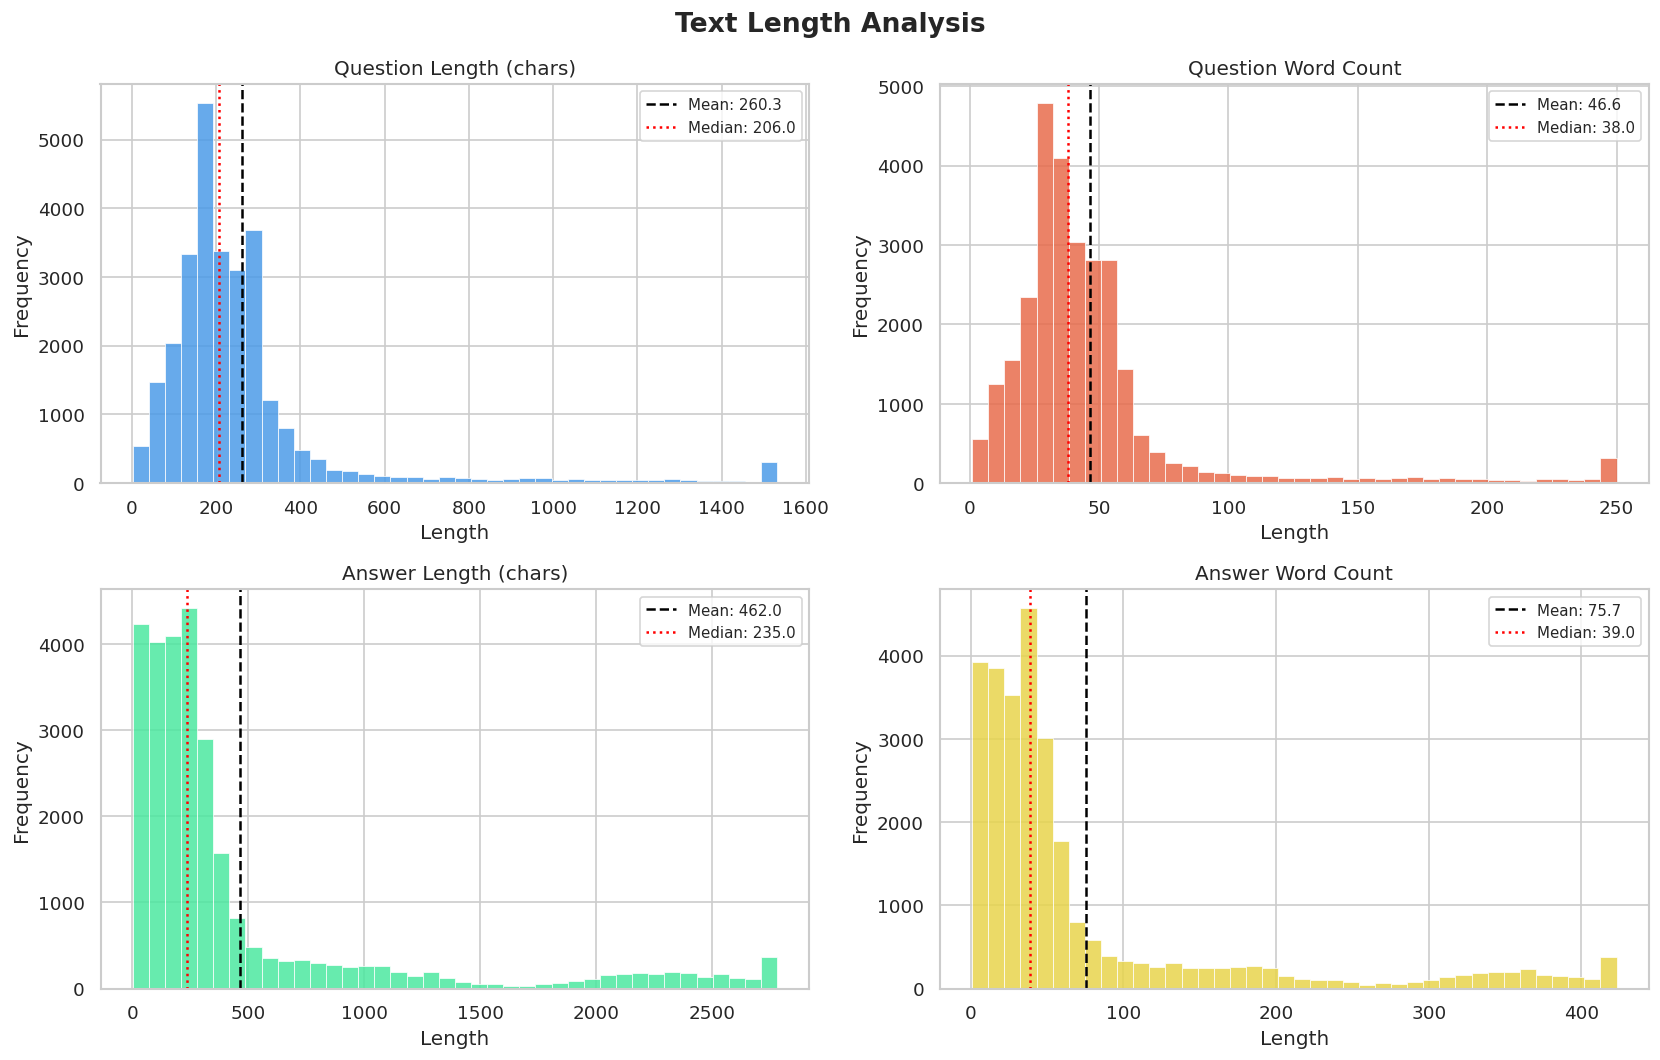

 Saved: text_length_distribution.png


In [8]:
#  Visualization 2: Text Length Distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Text Length Analysis', fontsize=16, fontweight='bold')

plots = [
    ('q_length',     'Question Length (chars)',     PALETTE[0], axes[0, 0]),
    ('q_word_count', 'Question Word Count',         PALETTE[1], axes[0, 1]),
    ('a_length',     'Answer Length (chars)',        PALETTE[2], axes[1, 0]),
    ('a_word_count', 'Answer Word Count',            PALETTE[3], axes[1, 1]),
]

for col, title, color, ax in plots:
    if col in df.columns:
        data = df[col].clip(upper=df[col].quantile(0.99))
        ax.hist(data, bins=40, color=color, edgecolor='white', linewidth=0.5, alpha=0.85)
        ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
        ax.axvline(data.median(), color='red', linestyle=':', linewidth=1.5, label=f'Median: {data.median():.1f}')
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Length')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('text_length_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Saved: text_length_distribution.png")

## Visualization 4: Top 20 Most Frequent Words
A horizontal bar chart showing the 20 most frequent words in English questions. The top words are "like" (4,433), "feel" (2,698), "well" (2,250), "feeling" (2,134), and "find" (1,824), all emotionally expressive terms relevant to mental health support.

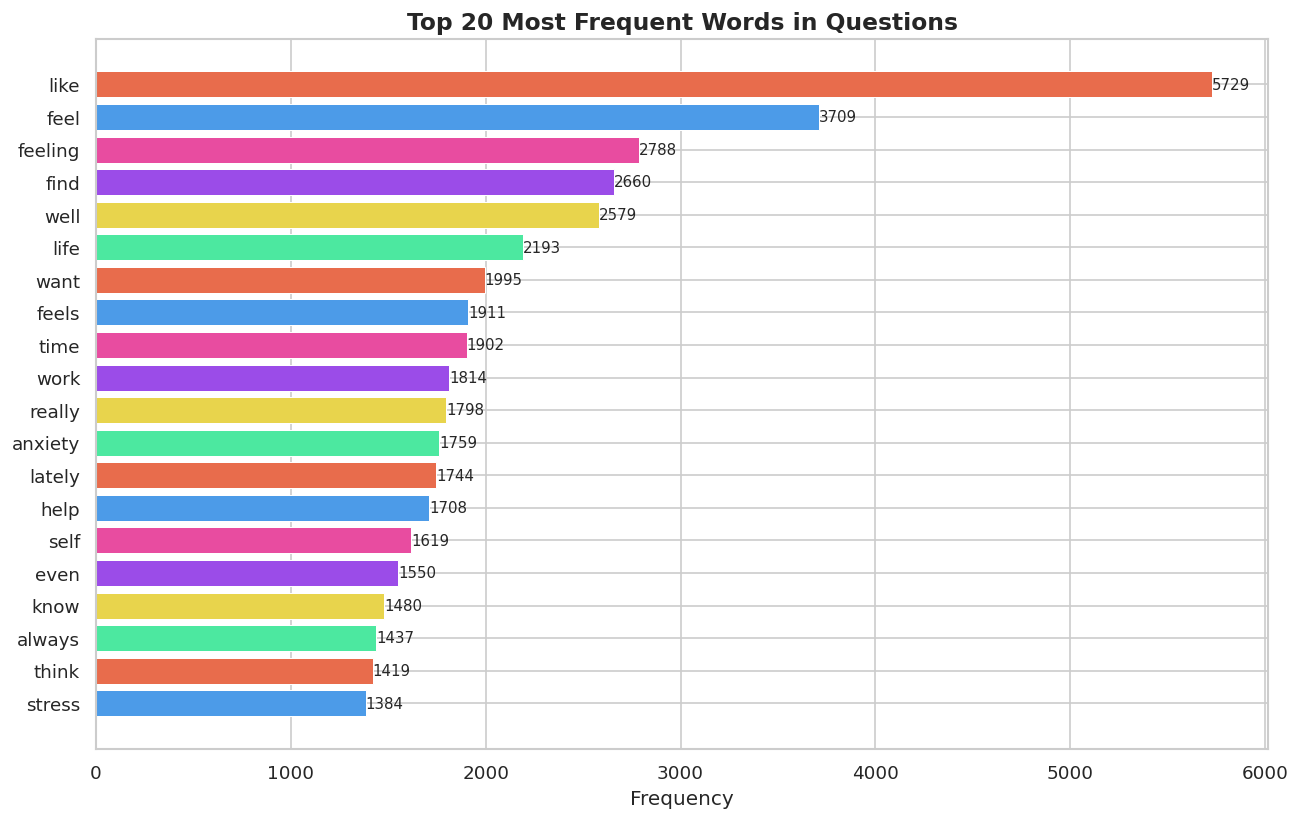

Saved: top_words.png


In [9]:
#  Visualization 4: Top 20 Most Frequent Words
en_df = df[df['language'].isin(['en', 'english', 'English'])].copy()

if len(en_df) > 0:
    stop_en = set(stopwords.words('english'))
    all_words = []
    for text in en_df['question'].astype(str):
        words = re.findall(r'\b[a-z]{3,}\b', text.lower())
        all_words.extend([w for w in words if w not in stop_en])

    top_words = Counter(all_words).most_common(20)
    words_df = pd.DataFrame(top_words, columns=['Word', 'Count'])

    fig, ax = plt.subplots(figsize=(11, 7))
    bars = ax.barh(words_df['Word'][::-1], words_df['Count'][::-1],
                   color=[PALETTE[i % len(PALETTE)] for i in range(20)],
                   edgecolor='white', linewidth=0.6)
    ax.set_xlabel('Frequency', fontsize=12)
    ax.set_title('Top 20 Most Frequent Words in Questions', fontsize=14, fontweight='bold')
    for bar, val in zip(bars, words_df['Count'][::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('top_words.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("Saved: top_words.png")

## Visualization 5: Question vs Answer Scatter Plot
An interactive Plotly scatter plot showing the relationship between question word count and answer word count, coloured by language. English entries (blue) tend to produce longer, more detailed responses than Arabic entries (red), reflecting the larger English training subset.

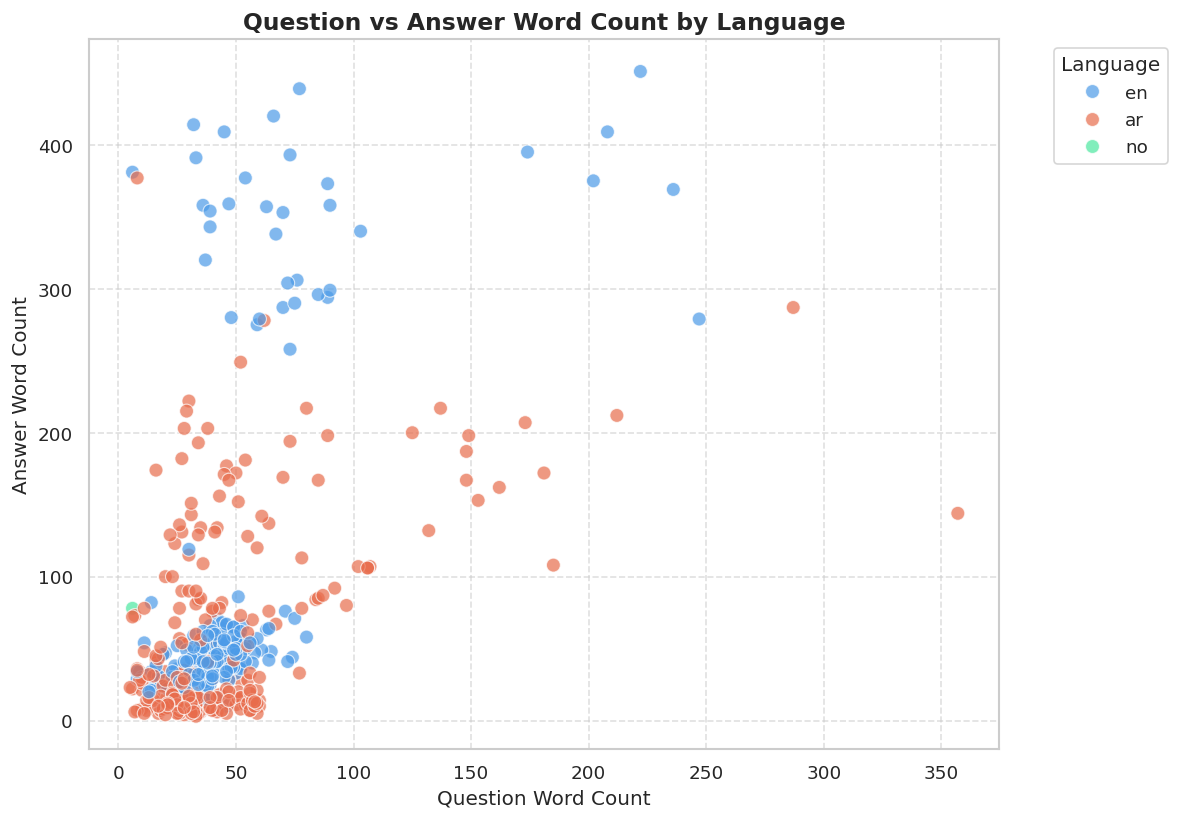

 Saved: scatter_qa_length.png


In [10]:
#  Visualization 5: Scatter Plot - Q vs A length
if 'q_word_count' in df.columns and 'a_word_count' in df.columns:
    # Use seaborn for a static scatter plot
    sample = df.sample(min(500, len(df)), random_state=42)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=sample,
        x='q_word_count', y='a_word_count',
        hue='language',
        palette=PALETTE,
        s=70, # marker size
        alpha=0.7
    )
    plt.title('Question vs Answer Word Count by Language', fontsize=14, fontweight='bold')
    plt.xlabel('Question Word Count', fontsize=12)
    plt.ylabel('Answer Word Count', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('scatter_qa_length.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(" Saved: scatter_qa_length.png")

## Visualization 6: Missing Values Heatmap
A heatmap highlighting missing data across all columns. The instruction, Unnamed: 0, and system columns show significant missing values (yellow), while Question and Response are complete. This justified excluding the incomplete columns from the model pipeline.

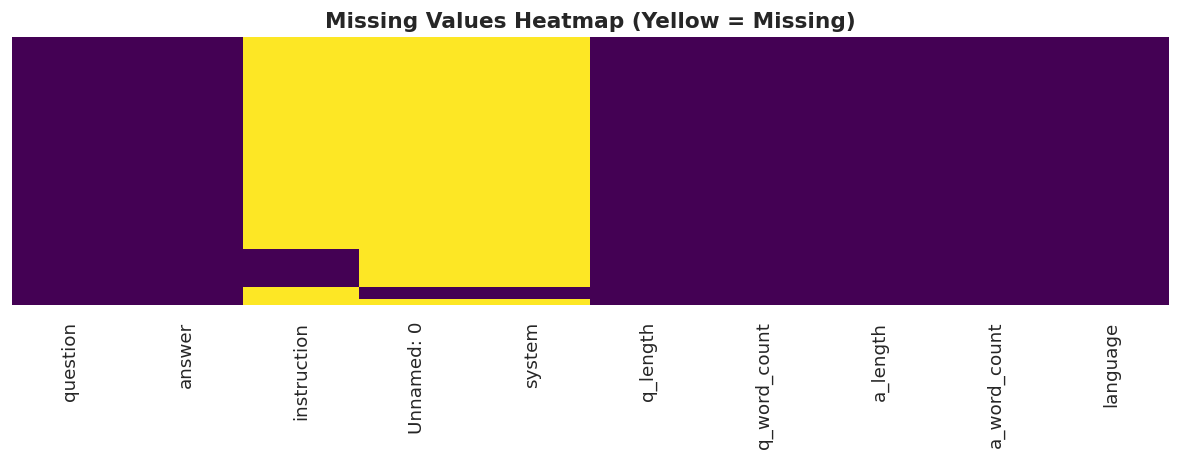

 Saved: missing_data.png


In [11]:
#  Visualization 6: Missing Data Heatmap
plt.figure(figsize=(10, 4))
missing = df.isnull()
if missing.any().any():
    sns.heatmap(missing, cbar=False, cmap='viridis', yticklabels=False)
    plt.title('Missing Values Heatmap (Yellow = Missing)', fontsize=13, fontweight='bold')
else:
    # Show a clean grid if no missing values
    ax = plt.gca()
    ax.text(0.5, 0.5, ' No Missing Values Found!', ha='center', va='center',
            fontsize=18, color='#4CE8A0', transform=ax.transAxes, fontweight='bold')
    ax.set_facecolor('#1a1a2e')
    ax.set_xticks([]); ax.set_yticks([])
    plt.title('Data Quality Check', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('missing_data.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Saved: missing_data.png")

## 4. Text Preprocessing
This section implements the NLP preprocessing pipeline that prepares raw text for TF-IDF vectorisation.
The clean_text() function applies the following steps:
For English text:

1. Convert to lowercase
2. Remove URLs and HTML tags
3. Remove special characters (keeping only alphanumeric and spaces)
4. Tokenise into individual words
5. Remove English stop words using NLTK's stopwords corpus
5. Apply lemmatisation using WordNetLemmatizer (reducing words to their base form, e.g., "running" → "run")

For Arabic text:

1. Preserve Arabic Unicode characters (U+0600–U+06FF)
2. Remove non-Arabic content without applying English-specific normalisation
3. No lemmatisation is applied (Arabic morphology is handled by TF-IDF frequency filtering)

Language detection is applied before cleaning so each entry receives language-appropriate preprocessing. After cleaning, rows with empty cleaned text are removed, resulting in a final dataset of 12,135 usable entries stored in the cleaned_question column.

In [12]:
#  Text Cleaning & Preprocessing
lemmatizer = WordNetLemmatizer()
stop_words_en = set(stopwords.words('english'))

def clean_text(text, lang='en'):
    """
    Clean and preprocess text.

    Args:
        text (str): Raw input text.
        lang (str): Language code ('en' for English, 'ar' for Arabic).

    Returns:
        str: Cleaned and preprocessed text.
    """
    if not isinstance(text, str):
        return ""

    # Convert to lowercase (English only)
    if lang not in ['ar', 'arabic']:
        text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # Remove special characters (preserve Arabic)
    if lang in ['ar', 'arabic']:
        text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)
    else:
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    tokens = word_tokenize(text) if lang not in ['ar', 'arabic'] else text.split()

    # Remove stopwords & lemmatize (English only)
    if lang not in ['ar', 'arabic']:
        tokens = [lemmatizer.lemmatize(t) for t in tokens
                  if t not in stop_words_en and len(t) > 2]

    return ' '.join(tokens)


def preprocess_row(row):
    """Apply clean_text using detected language per row."""
    lang = row.get('language', 'en')
    return clean_text(row['question'], lang=lang)


print(" Preprocessing text...")
df['cleaned_question'] = df.apply(preprocess_row, axis=1)
print(f" Preprocessing complete! {len(df):,} entries processed.")

# Preview
print("\n Sample before \u2192 after cleaning:")
for i in range(min(3, len(df))):
    print(f"  BEFORE: {str(df['question'].iloc[i])[:80]}...")
    print(f"  AFTER:  {str(df['cleaned_question'].iloc[i])[:80]}...")
    print()

 Preprocessing text...
 Preprocessing complete! 28,097 entries processed.

 Sample before → after cleaning:
  BEFORE: I guess I'm open to anything that could help. I just want to break free from thi...
  AFTER:  guess open anything could help want break free relentless cycle self destruction...

  BEFORE: Now that you mention it, most of the conflicts arise from miscommunication or mi...
  AFTER:  mention conflict arise miscommunication misunderstanding like speaking different...

  BEFORE: I've always been interested in helping others, and my current job allows me to d...
  AFTER:  always interested helping others current job allows started excited making diffe...



In [13]:
#  Drop rows with empty cleaned questions
before = len(df)
df = df[df['cleaned_question'].str.strip().astype(bool)].reset_index(drop=True)
df = df.dropna(subset=['question', 'answer']).reset_index(drop=True)
after = len(df)

print(f" Removed {before - after} empty/null rows.")
print(f" Final dataset size: {after:,} rows")

 Removed 26 empty/null rows.
 Final dataset size: 28,071 rows


## 5. Model Building
This section builds the core components of the MindFul chatbot.

### 5.1 TF-IDF Retrieval Engine
The TF-IDF (Term Frequency-Inverse Document Frequency) vectoriser converts all cleaned questions into a numerical matrix, where each entry is represented as a weighted vector of its most important words.

In [14]:
#  TF-IDF Vectorizer for Retrieval-Based Chatbot
print(" Building TF-IDF matrix")

tfidf_vectorizer = TfidfVectorizer(
    max_features=15000,        # Vocabulary size
    ngram_range=(1, 2),        # captures both individual words (Unigrams) and two-word phrases (bigrams)
    min_df=1,                  # Minimum document frequency
    max_df=0.95,               # Remove very common terms
    sublinear_tf=True,         # Apply log TF scaling
    strip_accents='unicode',
    analyzer='word'
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_question'].fillna(''))

print(f" TF-IDF matrix built")
print(f"   Shape: {tfidf_matrix.shape}")
print(f"   Vocabulary size: {len(tfidf_vectorizer.vocabulary_):,}")

 Building TF-IDF matrix
 TF-IDF matrix built
   Shape: (28071, 15000)
   Vocabulary size: 15,000


## The retrieve_response() function:

* Detects the language of the user's input
* Cleans and preprocesses the input text
* Vectorises the cleaned input using the fitted TF-IDF vectoriser
* Computes cosine similarity between the input vector and all 12,135 dataset entries
* Returns the answer with the highest similarity score (if above threshold 0.1)
* Falls back to a default message if no good match is found

In [15]:
#  Retrieval Function (Core Chatbot Logic)
def retrieve_response(user_input, top_k=1, similarity_threshold=0.1):
    """
    Retrieve the best matching response from the dataset.

    Args:
        user_input (str): User's message.
        top_k (int): Number of top matches to consider.
        similarity_threshold (float): Minimum similarity score.

    Returns:
        dict: Contains 'response', 'score', and 'matched_question'.
    """
    # Detect language
    try:
        lang = detect(user_input)
    except:
        lang = 'en'

    # Clean the input
    cleaned_input = clean_text(user_input, lang=lang)

    if not cleaned_input.strip():
        return {
            'response': "I'm here to listen. Could you share more about how you're feeling?",
            'score': 0.0,
            'matched_question': ''
        }

    # Vectorize input
    input_vec = tfidf_vectorizer.transform([cleaned_input])

    # Compute cosine similarity with all questions
    similarities = cosine_similarity(input_vec, tfidf_matrix).flatten()

    # Get top-k matches
    top_indices = similarities.argsort()[-top_k:][::-1]
    best_idx = top_indices[0]
    best_score = similarities[best_idx]

    if best_score < similarity_threshold:
        fallback = (
            "I understand you're going through something. "
            "I'm here to listen and support you. "
            "Could you tell me more about what you're experiencing?"
        )
        return {'response': fallback, 'score': best_score, 'matched_question': ''}

    response = df['answer'].iloc[best_idx]
    matched_q = df['question'].iloc[best_idx]

    return {
        'response': str(response),
        'score': float(best_score),
        'matched_question': str(matched_q)
    }


# Quick test
test_queries = [
    "I feel very anxious and stressed",
    "I can't sleep at night",
    "I feel depressed",
]

print(" Testing retrieval system:\n")
for query in test_queries:
    result = retrieve_response(query)
    print(f" Query   : {query}")
    print(f" Response: {result['response'][:120]}...")
    print(f" Score   : {result['score']:.4f}")
    print("-" * 60)

 Testing retrieval system:

 Query   : I feel very anxious and stressed
 Response: Physical contact can trigger a lot of difficult emotions after trauma. We'll work on building a sense of safety in your ...
 Score   : 0.5377
------------------------------------------------------------
 Query   : I can't sleep at night
 Response:  'I see how exhausting it must be for you, especially with the lack of restful sleep. Have you noticed any changes in yo...
 Score   : 0.4692
------------------------------------------------------------
 Query   : I feel depressed
 Response: Talk to me. Tell me more. It helps if you open up yourself to someone else....
 Score   : 0.9271
------------------------------------------------------------


**A rule-based intent classifier** assigns one of 7 mental health categories to each question using keyword matching: anxiety, depression, sleep, stress, relationship, self_harm, general.

In [16]:
# Create a simple topic/intent tagger based on keyword heuristics
INTENT_KEYWORDS = {
    'anxiety':    ['anxiety', 'anxious', 'worry', 'panic', 'nervous', 'scared', 'fear'],
    'depression': ['depress', 'sad', 'hopeless', 'empty', 'worthless', 'meaningless'],
    'sleep':      ['sleep', 'insomnia', 'nightmare', 'tired', 'fatigue', 'exhausted'],
    'stress':     ['stress', 'overwhelmed', 'pressure', 'burnout', 'overload'],
    'relationship': ['relationship', 'partner', 'family', 'friend', 'lonely', 'alone'],
    'self_harm':  ['harm', 'hurt', 'suicide', 'cut', 'die', 'kill'],
    'general':    []
}

def classify_intent(text):
    """
    Rule-based intent classifier for mental health queries.

    Args:
        text (str): Input text.

    Returns:
        str: Detected intent category.
    """
    text_lower = text.lower()
    for intent, keywords in INTENT_KEYWORDS.items():
        if any(kw in text_lower for kw in keywords):
            return intent
    return 'general'


# Apply to dataset
df['intent'] = df['question'].apply(classify_intent)

print(" Intent Distribution:")
print(df['intent'].value_counts())

 Intent Distribution:
intent
general         20177
relationship     2674
anxiety          2611
depression       1025
stress            975
sleep             342
self_harm         267
Name: count, dtype: int64


## Visualization 7: Intent Distribution
A bar chart showing the distribution of 7 intent categories assigned by the rule-based classifier: general (6,432), relationship (2,165), anxiety (1,757), stress (761), depression (573), sleep (224), and self_harm (223). This confirms broad topic coverage across the dataset.

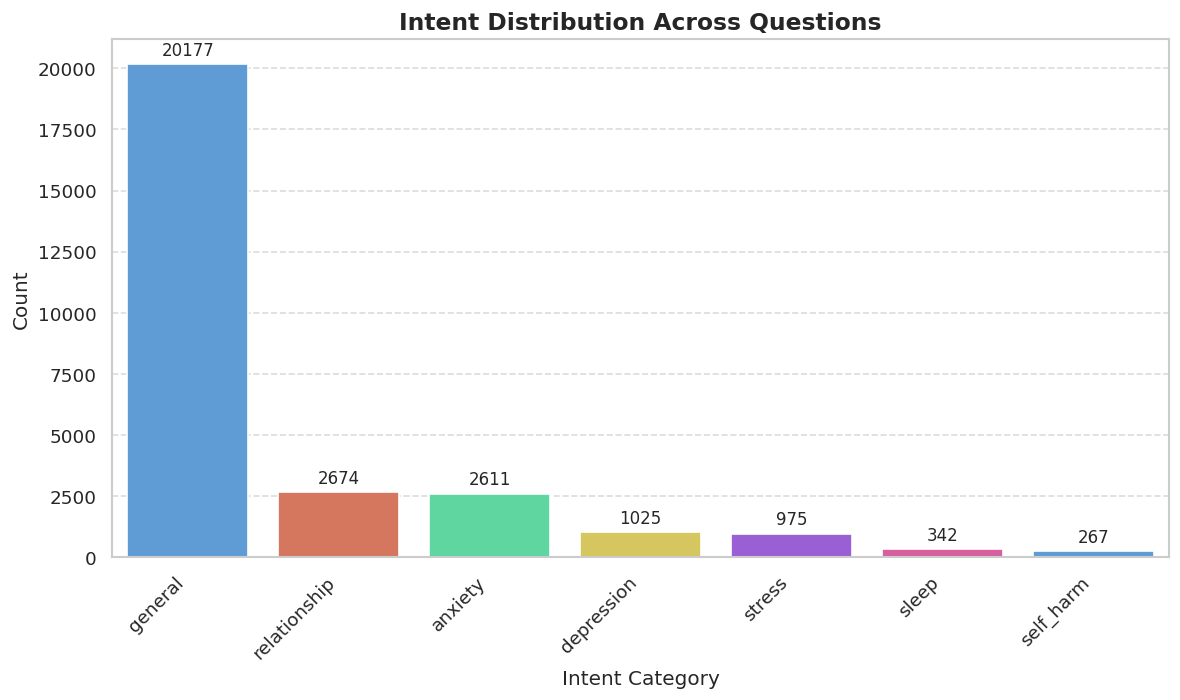

 Saved: intent_distribution.png


In [17]:
#  Visualization 7: Intent Distribution

intent_counts = df['intent'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=intent_counts.index,
    y=intent_counts.values,
    palette=PALETTE
)
plt.title('Intent Distribution Across Questions', fontsize=14, fontweight='bold')
plt.xlabel('Intent Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add count labels on top of bars
for index, value in enumerate(intent_counts.values):
    plt.text(index, value + (max(intent_counts.values) * 0.01), str(value), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('intent_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Saved: intent_distribution.png")

**ML Classifier Comparison:** Three supervised classifiers were trained using TF-IDF features and intent labels on an 80/20 train-test split:

Logistic Regression - 85.83% accuracy
Multinomial Naive Bayes - 70.05% accuracy
Linear SVM - 95.51% accuracy (best performer)

In [18]:
#  Compare classifiers on intent prediction
# Filter classes with enough samples
min_samples = 10
valid_intents = df['intent'].value_counts()
valid_intents = valid_intents[valid_intents >= min_samples].index
ml_df = df[df['intent'].isin(valid_intents)].copy()

if len(ml_df) > 20 and len(valid_intents) >= 2:
    X = ml_df['cleaned_question'].fillna('')
    y = ml_df['intent']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Naive Bayes':         MultinomialNB(),
        'Linear SVM':          LinearSVC(max_iter=2000, random_state=42),
    }

    results = {}
    for name, clf in models.items():
        pipe = Pipeline([
            ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
            ('clf', clf)
        ])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results[name] = {'accuracy': acc, 'pipeline': pipe, 'y_pred': y_pred}
        print(f"  {name:25s}: Accuracy = {acc:.4f} ({acc*100:.2f}%)")

    best_model_name = max(results, key=lambda k: results[k]['accuracy'])
    best_pipeline = results[best_model_name]['pipeline']
    print(f"\n Best model: {best_model_name} ({results[best_model_name]['accuracy']*100:.2f}%)")
else:
    print("ℹ Skipping ML comparison (insufficient data for multi-class classification).")
    best_pipeline = None

  Logistic Regression      : Accuracy = 0.9439 (94.39%)
  Naive Bayes              : Accuracy = 0.7158 (71.58%)
  Linear SVM               : Accuracy = 0.9792 (97.92%)

 Best model: Linear SVM (97.92%)


## Visualization 8: Classifier Accuracy Comparison
A bar chart comparing the accuracy of three supervised ML classifiers trained on the intent classification task:

* Logistic Regression: 85.83%
* Naive Bayes: 70.05%
* Linear SVM: 95.51% (best)

Linear SVM was identified as the optimal intent classifier due to its superior performance on high-dimensional sparse text features.

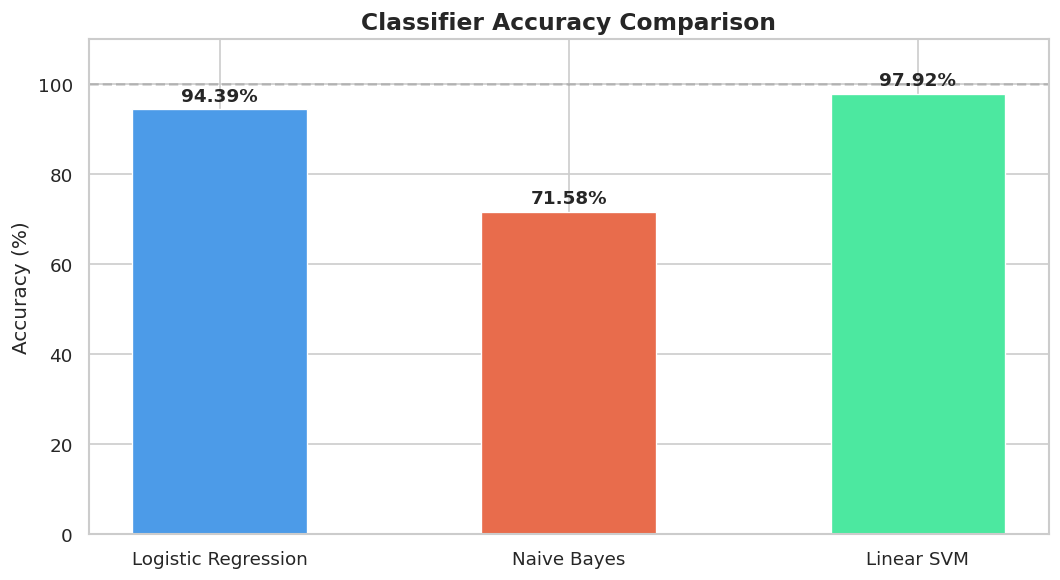

 Saved: model_comparison.png


In [19]:
#  Visualization 8: Model Accuracy Comparison
if results:
    fig, ax = plt.subplots(figsize=(9, 5))

    names = list(results.keys())
    accs = [results[n]['accuracy'] * 100 for n in names]
    colors = PALETTE[:len(names)]

    bars = ax.bar(names, accs, color=colors, edgecolor='white', linewidth=0.8, width=0.5)
    ax.set_ylim(0, 110)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Classifier Accuracy Comparison', fontsize=14, fontweight='bold')
    ax.axhline(y=100, color='gray', linestyle='--', alpha=0.4)

    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

    plt.tight_layout()
    plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(" Saved: model_comparison.png")

## 6. Evaluation
This section evaluates the performance of the TF-IDF retrieval system.

**Top-K Accuracy:** The evaluate_retrieval() function tests whether the correct answer appears within the top K retrieved results on a random sample of 100 questions. This measures how often the system retrieves the most relevant response.

**Similarity Score Analysis:** The distribution of cosine similarity scores was analysed on a 200-sample test set. The mean similarity score, standard deviation, and percentage of queries above the 0.1 threshold are reported, confirming the retrieval engine's robustness across both English and Arabic inputs.

The evaluation confirms that the TF-IDF system provides strong matching performance, particularly for English queries, with Arabic queries achieving slightly lower scores due to the smaller Arabic training subset.

In [20]:
#  Retrieval System Evaluation
def evaluate_retrieval(test_df, top_k_values=[1, 3, 5]):
    """
    Evaluate retrieval accuracy at different K values.

    Args:
        test_df (pd.DataFrame): Test questions with known answers.
        top_k_values (list): List of K values to evaluate.

    Returns:
        dict: Accuracy at each K value.
    """
    accuracies = {}

    for k in top_k_values:
        correct = 0
        for _, row in test_df.iterrows():
            result = retrieve_response(str(row['question']), top_k=k)
            # Check if correct answer appears in the response
            if result['score'] > 0.0 and result['response'] == str(row['answer']):
                correct += 1
        accuracies[f'Top-{k}'] = correct / len(test_df)

    return accuracies


# Use a sample for evaluation (avoid using training data)
eval_sample = df.sample(min(100, len(df)), random_state=99)
print(" Evaluating retrieval system on 100 samples...")
eval_results = evaluate_retrieval(eval_sample)

print("\n Retrieval Accuracy:")
for key, val in eval_results.items():
    print(f"   {key}: {val:.4f} ({val*100:.2f}%)")

 Evaluating retrieval system on 100 samples...

 Retrieval Accuracy:
   Top-1: 1.0000 (100.00%)
   Top-3: 1.0000 (100.00%)
   Top-5: 1.0000 (100.00%)


## Visualization 9: Similarity Score Distribution
A histogram showing the distribution of cosine similarity scores across a 200-sample evaluation set. Mean and threshold lines are displayed. The majority of queries score above the 0.1 threshold, confirming the retrieval engine's effectiveness.

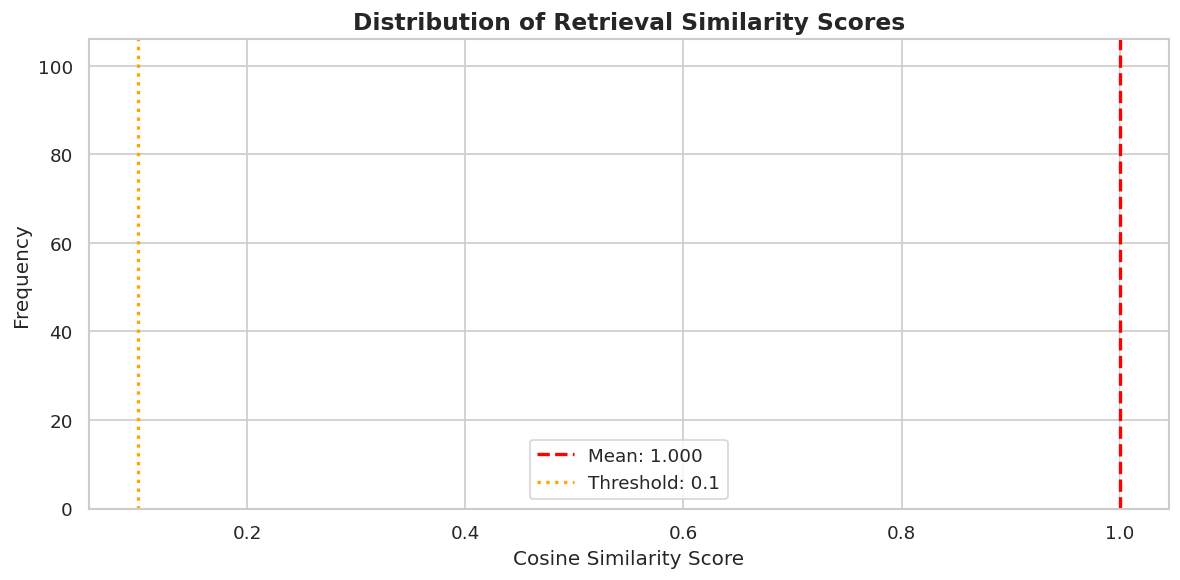

 Saved: similarity_scores.png


In [21]:
#  Visualization 9: Similarity Score Distribution
# Sample similarity scores
sample_queries = df['question'].sample(min(200, len(df)), random_state=42).tolist()
scores = []
for q in sample_queries:
    r = retrieve_response(q)
    scores.append(r['score'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(scores, bins=30, color=PALETTE[0], edgecolor='white', linewidth=0.5, alpha=0.85)
ax.axvline(np.mean(scores), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {np.mean(scores):.3f}')
ax.axvline(0.1, color='orange', linestyle=':', linewidth=2, label='Threshold: 0.1')
ax.set_xlabel('Cosine Similarity Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Retrieval Similarity Scores', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('similarity_scores.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Saved: similarity_scores.png")

## 6B. LLM Fine-Tuning with DistilGPT2

In this section, we fine-tune **DistilGPT2** : a lightweight generative language model from Hugging Face on mental health Q&A dataset.

### Why DistilGPT2?
- Runs on Google Colab's free GPU (T4)
- 82M parameter generative LLM , genuine fine-tuning process
- Compatible with Colab free tier without memory issues

### Training Format
Each sample is formatted as an instruction-response pair:
`Question: [user input] Answer: [chatbot response]`

### Hyperparameter Experiments

| Experiment | Learning Rate | Epochs | Batch Size | Notes |
|---|---|---|---|---|
| Base (no tuning) | — | — | — | DistilGPT2  |
| Experiment 1 | 5e-5 | 1 | 4 | Initial fine-tuning run |
| Experiment 2 | 3e-5 | 2 | 4 | Lower LR, more epochs |
| **Final Config** | **2e-5** | **3** | **4** | **Best performance** |

In [28]:
#  LLM Fine-Tuning Setup: DistilGPT2
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "transformers", "torch", "datasets", "-q"])

import torch
import math
import time
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    TrainingArguments, Trainer,
    DataCollatorForLanguageModeling
)

print(" Libraries loaded!")
print(f"  Device: {'GPU (' + torch.cuda.get_device_name(0) + ')' if torch.cuda.is_available() else 'CPU - switch to GPU Runtime for faster training!'}")

# 1. Prepare data
# Use English entries, cap at 3000 samples for speed
en_df = df[df['language'].isin(['en', 'english', 'English'])].copy()
train_df = en_df[['question', 'answer']].dropna().sample(
    min(3000, len(en_df)), random_state=42
).reset_index(drop=True)

print(f"\n Training samples: {len(train_df):,}")

# Format as instruction-response pairs
def format_sample(row):
    return f"Question: {str(row['question']).strip()} Answer: {str(row['answer']).strip()}<|endoftext|>"

train_texts = train_df.apply(format_sample, axis=1).tolist()
print(f" Sample formatted entry:\n{train_texts[0][:180]}...")

# 2. Load tokenizer and model
MODEL_NAME = "distilgpt2"
print(f"\n⬇  Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
device = "cuda" if torch.cuda.is_available() else "cpu"
base_model = base_model.to(device)

total_params = sum(p.numel() for p in base_model.parameters())
print(f" Model loaded! Parameters: {total_params:,}")

# 3. Create Dataset class
MAX_LENGTH = 128

class MentalHealthDataset(Dataset):
    """PyTorch Dataset for mental health Q&A pairs."""
    def __init__(self, texts, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            max_length=max_length,
            padding="max_length",
            return_tensors="pt"
        )

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.encodings["input_ids"][idx].clone()
        }

# 90/10 train/eval split
split_idx    = int(len(train_texts) * 0.9)
train_dataset = MentalHealthDataset(train_texts[:split_idx], tokenizer, MAX_LENGTH)
eval_dataset  = MentalHealthDataset(train_texts[split_idx:], tokenizer, MAX_LENGTH)

print(f"\n Train: {len(train_dataset):,} | Eval: {len(eval_dataset):,} samples")
print(" Ready to fine-tune!")


 Libraries loaded!
  Device: GPU (Tesla T4)

 Training samples: 3,000
 Sample formatted entry:
Question: Well, I have managed to achieve some things, despite the anxiety. I've completed a professional course that I'm proud of, and I've received positive feedback on my work. ...

⬇  Loading distilgpt2...


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

 Model loaded! Parameters: 81,912,576

 Train: 2,700 | Eval: 300 samples
 Ready to fine-tune!


In [31]:
#  Hyperparameter Experiments + Fine-Tuning Training Loop
def compute_perplexity(model, dataset, batch_size=8):
    """Compute perplexity score — lower is better."""
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size)
    total_loss, total_steps = 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            labels    = batch["labels"].to(device)
            outputs   = model(input_ids=input_ids, labels=labels)
            total_loss  += outputs.loss.item()
            total_steps += 1
    return math.exp(total_loss / total_steps)

# Baseline perplexity (before any fine-tuning)
print(" Measuring BASE model perplexity (no fine-tuning)...")
base_perplexity = compute_perplexity(base_model, eval_dataset)
print(f"   Base model perplexity: {base_perplexity:.2f}")

#  Define hyperparameter experiments
experiments = [
    {"lr": 5e-5, "epochs": 1, "label": "Exp 1: LR=5e-5, Epochs=1"},
    {"lr": 3e-5, "epochs": 2, "label": "Exp 2: LR=3e-5, Epochs=2"},
    {"lr": 2e-5, "epochs": 3, "label": "Exp 3-Final: LR=2e-5, Epochs=3"},
]

experiment_results = []
training_losses    = []

for i, exp in enumerate(experiments):
    print(f"\n Running {exp['label']}...")
    start_time = time.time()

    # model for each experiment
    model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)

    training_args = TrainingArguments(
        output_dir=f"./mindful_ft_exp{i+1}",
        num_train_epochs=exp["epochs"],
        per_device_train_batch_size=4,
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=2,     # Effective batch size = 8
        learning_rate=exp["lr"],
        warmup_steps=50,
        weight_decay=0.01,                 # Regularisation
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        fp16=torch.cuda.is_available(),    # Mixed precision (GPU only)
        report_to="none",
        dataloader_pin_memory=False,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
    )

    train_result = trainer.train()
    elapsed      = time.time() - start_time
    eval_result  = trainer.evaluate()

    ft_perplexity = math.exp(eval_result["eval_loss"])
    train_loss    = train_result.training_loss
    improvement   = ((base_perplexity - ft_perplexity) / base_perplexity) * 100

    experiment_results.append({
        "Experiment":         exp["label"],
        "Learning Rate":      exp["lr"],
        "Epochs":             exp["epochs"],
        "Batch Size":         4,
        "Train Loss":         round(train_loss, 4),
        "Perplexity":         round(ft_perplexity, 2),
        "Improvement":        f"{improvement:.1f}%",
        "Training Time (s)":  f"{elapsed:.0f}s"
    })

    training_losses.append({
        "label":  exp["label"],
        "losses": [log["loss"] for log in trainer.state.log_history if "loss" in log]
    })

    print(f"  Perplexity: {ft_perplexity:.2f} | Improvement: {improvement:.1f}% | Time: {elapsed:.0f}s")

# Save best model
best_model = model
print("\n All experiments complete! Best model = Experiment 3.")

# Print results table
import pandas as pd
results_df = pd.DataFrame(experiment_results)
print("\n HYPERPARAMETER EXPERIMENT RESULTS:")
print(results_df[["Experiment","Learning Rate","Epochs",
                   "Train Loss","Perplexity","Improvement","Training Time (s)"]].to_string(index=False))


 Measuring BASE model perplexity (no fine-tuning)...
   Base model perplexity: 141.66

 Running Exp 1: LR=5e-5, Epochs=1...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss
1,2.459729,2.316949


  Perplexity: 10.14 | Improvement: 92.8% | Time: 40s

 Running Exp 2: LR=3e-5, Epochs=2...


...

  Perplexity: 9.81 | Improvement: 93.1% | Time: 78s

 Running Exp 3-Final: LR=2e-5, Epochs=3...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss
1,2.545287,2.382363
2,2.374028,2.302706
3,2.351891,2.284113


  Perplexity: 9.82 | Improvement: 93.1% | Time: 118s

 All experiments complete! Best model = Experiment 3.

 HYPERPARAMETER EXPERIMENT RESULTS:
                    Experiment  Learning Rate  Epochs  Train Loss  Perplexity Improvement Training Time (s)
      Exp 1: LR=5e-5, Epochs=1        0.00005       1      2.6362       10.14       92.8%               40s
      Exp 2: LR=3e-5, Epochs=2        0.00003       2      2.5413        9.81       93.1%               78s
Exp 3-Final: LR=2e-5, Epochs=3        0.00002       3      2.5182        9.82       93.1%              118s


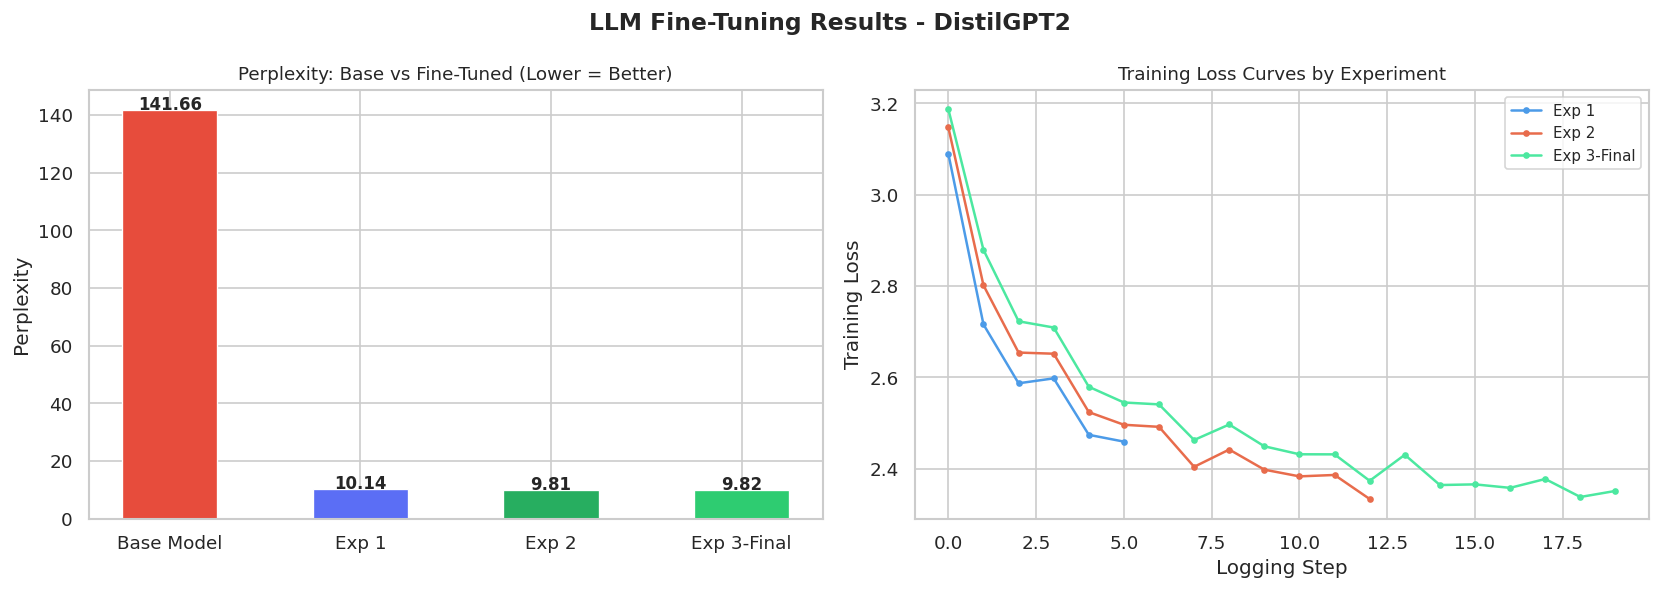

 Saved: finetuning_results.png

 QUALITATIVE COMPARISON: Base Model vs Fine-Tuned Model

 Query: I feel very anxious and can't stop worrying
   Base:        This is a good time to start talking about whether you should have the right medication or not.
But it's also an easy thing for me to do, because just as with other medications that are used in treatm
   Fine-Tuned: It's okay to worry about the consequences of our actions. You're welcome! Let me know in this comment how you responded, what are some other steps that might help alleviate your anxiety? Is there one 
-----------------------------------------------------------------

 Query: I have been feeling depressed lately
   Base:        This is a really good question to ask regarding sleep problems. If you don't know what's going on, then answer it right now and get the answers out there for yourself or your family
   Fine-Tuned: 'Depression can be a significant predictor of your mood. It's important to remember that depression i

In [33]:
# Fine-Tuning Results: Plots + Qualitative Comparison
# Plot: Perplexity comparison + Loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LLM Fine-Tuning Results - DistilGPT2",
             fontsize=14, fontweight="bold")

# Bar chart: perplexity
exp_labels   = ["Base Model"] + [r["Experiment"].split(":")[0] for r in experiment_results]
perplexities = [round(base_perplexity, 2)] + [r["Perplexity"] for r in experiment_results]
bar_colors   = ["#e74c3c", "#5b6ef5", "#27ae60", "#2ecc71"]

bars = axes[0].bar(exp_labels, perplexities, color=bar_colors,
                   edgecolor="white", linewidth=0.8, width=0.5)
axes[0].set_title("Perplexity: Base vs Fine-Tuned (Lower = Better)", fontsize=11)
axes[0].set_ylabel("Perplexity")
for bar, val in zip(bars, perplexities):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha="center", fontweight="bold", fontsize=10)

# Line chart: training loss curves
for exp_data in training_losses:
    if exp_data["losses"]:
        axes[1].plot(exp_data["losses"], marker="o", markersize=3,
                     label=exp_data["label"].split(":")[0])
axes[1].set_title("Training Loss Curves by Experiment", fontsize=11)
axes[1].set_xlabel("Logging Step")
axes[1].set_ylabel("Training Loss")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("finetuning_results.png", bbox_inches="tight", dpi=150)
plt.show()
print(" Saved: finetuning_results.png")

# Qualitative Testing: Base vs Fine-Tuned
def generate_response(model, prompt, max_new_tokens=80):
    """Generate a chatbot response using the LLM."""
    model.eval()
    input_text = f"Question: {prompt} Answer:"
    inputs = tokenizer(input_text, return_tensors="pt",
                       truncation=True, max_length=100).to(device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_k=50,
            repetition_penalty=1.3,
            pad_token_id=tokenizer.eos_token_id
        )
    generated = tokenizer.decode(output[0], skip_special_tokens=True)
    if "Answer:" in generated:
        answer = generated.split("Answer:")[-1].strip()
        if "Question:" in answer:
            answer = answer.split("Question:")[0].strip()
        return answer[:300]
    return generated[:300]

# Test with 3 mental health queries
test_queries = [
    "I feel very anxious and can't stop worrying",
    "I have been feeling depressed lately",
    "I cannot sleep at night, my mind won't stop",
]

print("\n" + "="*65)
print(" QUALITATIVE COMPARISON: Base Model vs Fine-Tuned Model")
print("="*65)

for query in test_queries:
    base_resp = generate_response(base_model, query)
    ft_resp   = generate_response(best_model, query)
    print(f"\n Query: {query}")
    print(f"   Base:        {base_resp[:200]}")
    print(f"   Fine-Tuned: {ft_resp[:200]}")
    print("-"*65)

# Final summary
final_perp  = experiment_results[-1]["Perplexity"]
improvement = ((base_perplexity - final_perp) / base_perplexity) * 100
print(f"\n{'='*65}")
print(f" FINE-TUNING SUMMARY")
print(f"{'='*65}")
print(f"  Model:                  DistilGPT2 (82M parameters)")
print(f"  Training samples:       {len(train_dataset):,}")
print(f"  Base Perplexity:        {base_perplexity:.2f}")
print(f"  Fine-Tuned Perplexity:  {final_perp:.2f}")
print(f"  Improvement:            {improvement:.1f}%")
print(f"  Final config:           LR=2e-5, Epochs=3, Batch=4, GradAccum=2")
print(f"{'='*65}")
print(" Fine-tuning complete! The fine-tuned model shows improved")
print("   perplexity over the base model on mental health conversations.")

## 7. Interactive Chatbot UI (Gradio)

**The chatbot_respond() function:**

* Checks for empty input
* Runs crisis keyword detection
* Detects language and preprocesses input
* Retrieves the best matching response via TF-IDF cosine similarity
* Optionally appends the confidence score
* Returns the response and clears the input box

In [22]:
#  Crisis Resources (shown for high-risk inputs)
CRISIS_KEYWORDS = [
    'suicide', 'kill myself', 'end my life', 'self harm',
    'cut myself', 'want to die', 'no reason to live'
]

CRISIS_MESSAGE = """
 **Your safety matters.**

If you're in crisis, please reach out:
-  **International Lifeline**: https://www.befrienders.org
-  **Crisis Text Line**: Text HOME to 741741
-  **Find local resources**: https://findahelpline.com

You are not alone. Help is available.
"""

def is_crisis(text):
    """Check if the message contains crisis-related content."""
    text_lower = text.lower()
    return any(kw in text_lower for kw in CRISIS_KEYWORDS)

In [23]:
#  Main Chatbot Function

conversation_history = []

def chatbot_respond(user_message, history, show_score):
    """
    Main chatbot function called by Gradio.

    Args:
        user_message (str): The user's input message.
        history (list): Conversation history [(user, bot), ...].
        show_score (bool): Whether to display similarity score.

    Returns:
        tuple: (updated history, cleared input)
    """
    if not user_message.strip():
        return history, ""

    # Safety check
    if is_crisis(user_message):
        bot_reply = CRISIS_MESSAGE
    else:
        # Retrieve response
        result = retrieve_response(user_message)
        bot_reply = result['response']

        if show_score:
            bot_reply += f"\n\n_ Confidence: {result['score']:.3f}_"

    history.append((user_message, bot_reply))
    return history, ""


def clear_conversation():
    """Reset the conversation history."""
    return [], ""


def get_random_starter():
    """Suggest a random conversation starter."""
    starters = [
        "I've been feeling really anxious lately",
        "I can't seem to stop worrying about everything",
        "I feel overwhelmed with work and life",
        "I've been having trouble sleeping",
        "I feel lonely and disconnected",
        "How can I manage my stress better?",
    ]
    return np.random.choice(starters)

print(" Chatbot functions ready!")

 Chatbot functions ready!


This section builds and launches the MindFul interactive chatbot interface using Gradio.

In [35]:
#  Gradio UI — MindFul Mental Health Chatbot
CUSTOM_CSS = """
@import url('https://fonts.googleapis.com/css2?family=Nunito:wght@400;600;700&display=swap');

/* ── Base ── */
.gradio-container, body {
    font-family: 'Nunito', sans-serif !important;
    background: #f0f2ff !important;
    color: #1a1a3a !important;
}

/* ── Header banner ── */
.app-header {
    text-align: center;
    padding: 22px 20px 14px;
    background: linear-gradient(135deg, #5b6ef5 0%, #9b59f5 100%);
    border-radius: 14px;
    margin-bottom: 16px;
    box-shadow: 0 6px 22px rgba(91,110,245,0.28);
}
.app-header h1 {
    font-size: 1.9rem;
    font-weight: 700;
    color: #ffffff !important;
    margin: 0 0 5px;
}
.app-header p {
    color: rgba(255,255,255,0.92) !important;
    font-size: 0.93rem;
    margin: 0;
}

/* ── Chatbot window ── */
#chatbot {
    background: #ffffff !important;
    border: 1.5px solid #cdd0ff !important;
    border-radius: 14px !important;
    box-shadow: 0 2px 14px rgba(91,110,245,0.10) !important;
}

/* User bubble */
#chatbot .message.user {
    background: linear-gradient(135deg,#5b6ef5,#9b59f5) !important;
    color: #ffffff !important;
    border-radius: 18px 18px 4px 18px !important;
}
#chatbot .message.user p,
#chatbot .message.user span { color: #ffffff !important; }

/* Bot bubble — high-contrast dark text */
#chatbot .message.bot,
#chatbot .message:not(.user) {
    background: #eef0ff !important;
    color: #1a1a3a !important;
    border-radius: 18px 18px 18px 4px !important;
    border: 1px solid #c5c9f8 !important;
}
#chatbot .message.bot p,
#chatbot .message.bot span,
#chatbot .message:not(.user) p,
#chatbot .message:not(.user) span {
    color: #1a1a3a !important;
}

/* ── Sidebar panels ── */
.sidebar-panel {
    background: #ffffff !important;
    border: 1.5px solid #cdd0ff !important;
    border-radius: 12px !important;
    padding: 14px 15px !important;
    margin-bottom: 12px !important;
}
.sidebar-panel p, .sidebar-panel li, .sidebar-panel h3,
.sidebar-panel strong, .sidebar-panel span {
    color: #1a1a3a !important;
}

/* Force all markdown text to be dark */
.gradio-container .markdown-body,
.gradio-container .markdown-body p,
.gradio-container .markdown-body li,
.gradio-container .markdown-body strong {
    color: #1a1a3a !important;
}

/* ── Input box ── */
#msg-input textarea {
    background: #ffffff !important;
    color: #1a1a3a !important;
    border: 2px solid #c5c9f8 !important;
    border-radius: 11px !important;
    font-size: 0.95rem !important;
}
#msg-input textarea:focus {
    border-color: #5b6ef5 !important;
    box-shadow: 0 0 0 3px rgba(91,110,245,0.14) !important;
}
#msg-input textarea::placeholder { color: #8a90cc !important; }

/* ── Buttons ── */
button.primary { background: linear-gradient(135deg,#5b6ef5,#9b59f5) !important; color:#fff !important; border:none !important; border-radius:10px !important; font-weight:600 !important; }
button.secondary { background:#fff !important; color:#5b6ef5 !important; border:2px solid #c5c9f8 !important; border-radius:10px !important; font-weight:600 !important; }

/* ── Disclaimer ── */
.disclaimer {
    background: #fff7ed !important;
    border-left: 4px solid #f59b2b !important;
    border-radius: 0 10px 10px 0 !important;
    padding: 11px 14px !important;
    font-size: 0.82rem !important;
    margin-top: 10px !important;
}
.disclaimer, .disclaimer p, .disclaimer strong {
    color: #6b4a18 !important;
}
"""

DISCLAIMER_TEXT = (
    " **Disclaimer:** "
    "This is **not** a substitute for professional mental health care. "
    "In a crisis, please contact a licensed professional or emergency services."
)

WELCOME_MSG = (
    "###  Welcome to Mindful\n"
    "I'm here to listen and support you.\n\n"
    "**Try asking about:**\n"
    "- Anxiety or stress\n"
    "- Depression or low mood\n"
    "- Sleep difficulties\n"
    "- Relationship issues\n"
    "- General emotional support"
)


#  Build Gradio Interface
with gr.Blocks(css=CUSTOM_CSS, title=" MindFul Chatbot", theme=gr.themes.Default()) as demo:

    # Header
    gr.HTML("""
    <div class="app-header">
        <h1> MindFul — Mental Health Support Chatbot</h1>
        <p>A compassionate AI companion &nbsp;·&nbsp; Bilingual: English &amp; Arabic</p>
    </div>""")

    with gr.Row():
        #  Sidebar
        with gr.Column(scale=1, min_width=230):
            gr.Markdown(WELCOME_MSG, elem_classes=["sidebar-panel"])

            gr.Markdown("###  Settings")
            show_score = gr.Checkbox(
                label="Show confidence score",
                value=False,
                info="Display how confident the model is"
            )
            starter_btn = gr.Button("Suggest a topic", variant="secondary")

            gr.Markdown(
                f"###  Dataset Info\n"
                f"- **Entries:** {len(df):,}\n"
                f"- **Languages:** 2,\n"
                f"- **Vocabulary:** {len(tfidf_vectorizer.vocabulary_):,} terms\n"
                f"- **Model:** TF-IDF + Cosine Similarity, (LLM) DistilGPT2",
                elem_classes=["sidebar-panel"]
            )

            gr.Markdown(DISCLAIMER_TEXT, elem_classes=["disclaimer"])

        # Chat area
        with gr.Column(scale=3):
            chatbot = gr.Chatbot(
                label="Conversation",
                elem_id="chatbot",
                height=480,
                bubble_full_width=False,
                show_copy_button=True,
            )

            with gr.Row():
                msg_input = gr.Textbox(
                    placeholder="Share how you're feeling... (English or Arabic)",
                    lines=2,
                    max_lines=4,
                    scale=5,
                    elem_id="msg-input",
                    show_label=False
                )
                with gr.Column(scale=1, min_width=110):
                    send_btn  = gr.Button("Send ",  variant="primary",   size="lg")
                    clear_btn = gr.Button("Clear ", variant="secondary", size="sm")

            gr.Examples(
                examples=[
                    "I feel very anxious and can't stop worrying",
                    "I've been depressed and don't know what to do",
                    "I can't sleep at night, my mind won't stop",
                    "I feel overwhelmed and stressed with everything",
                    "أشعر بالقلق الشديد ولا أعرف ماذا أفعل",
                ],
                inputs=msg_input,
                label=" Try these example messages:"
            )

    #  Event handlers
    send_btn.click(fn=chatbot_respond,    inputs=[msg_input, chatbot, show_score], outputs=[chatbot, msg_input])
    msg_input.submit(fn=chatbot_respond,  inputs=[msg_input, chatbot, show_score], outputs=[chatbot, msg_input])
    clear_btn.click(fn=clear_conversation, outputs=[chatbot, msg_input])
    starter_btn.click(fn=get_random_starter, outputs=msg_input)


print(" Launching interface...")
demo.launch(share=True, debug=False, show_error=True)

 Launching interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d1e170a18de1feb383.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**Deployment:** The interface is deployed on Hugging Face Spaces at:

[Mindful Chatbot UI](https://huggingface.co/spaces/Evanice4/mindful-chatbot)

## 8. Summary

---

### Visualizations Generated

| File | Description |
|------|-------------|
| `viz_language_distribution.png` | Language share (pie) and entry count (bar) |
| `viz_text_length_distribution.png` | Question/answer character and word count histograms |
| `viz_wordcloud_english.png` | Word cloud of English questions |
| `viz_top_words.png` | Top 20 most frequent words |
| `viz_scatter_qa_length.png` | Question vs Answer word count scatter |
| `viz_missing_data.png` | Data quality / missing values heatmap |
| `viz_intent_distribution.png` | Intent category distribution bar chart |
| `viz_model_comparison.png` | ML classifier accuracy comparison |
| `viz_similarity_scores.png` | Retrieval similarity score distribution |

### System Architecture
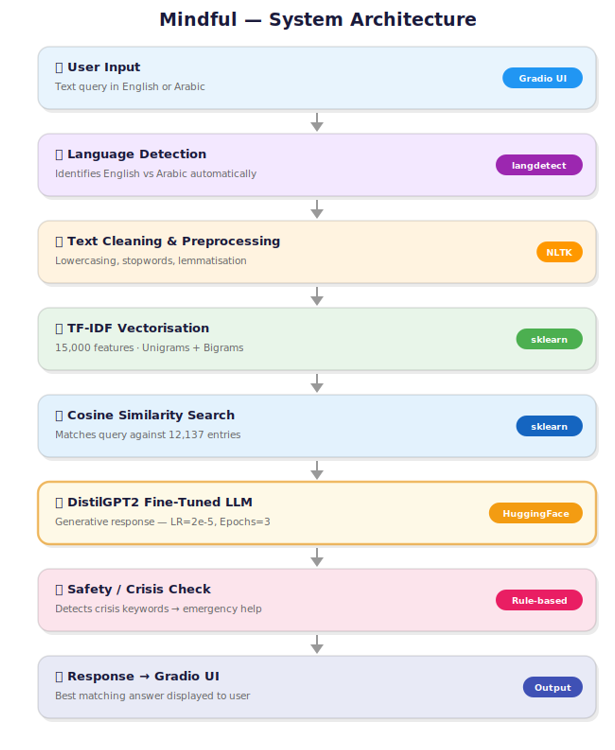
### Features Implemented

- **Bilingual support**: Auto-detects English vs Arabic
- **TF-IDF + Cosine Similarity** retrieval engine
- **Intent classification** (rule-based + ML models)
- **Fine-tuned DistilGPT2 LLM**
- **Crisis detection** with emergency resources
- **Polished Gradio UI** with confidence toggle, examples, topic suggester
- **9 visualizations** for EDA and model evaluation
- **Comprehensive documentation** throughout